In [10]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
folder_path = "CWRU/12k data/2_hp_load"
all_data_frames = [] # We use a list to stack our uneven data blocks

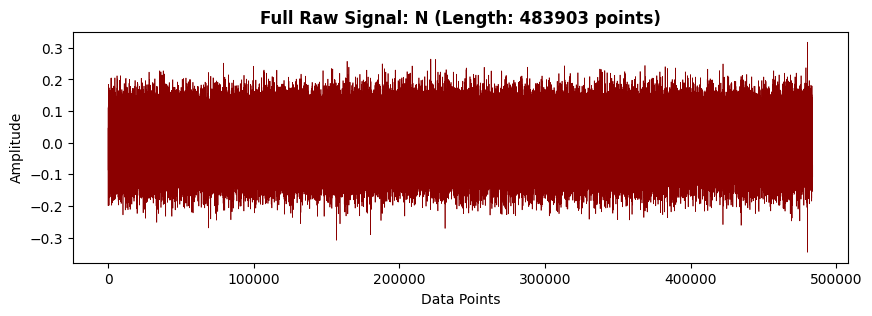

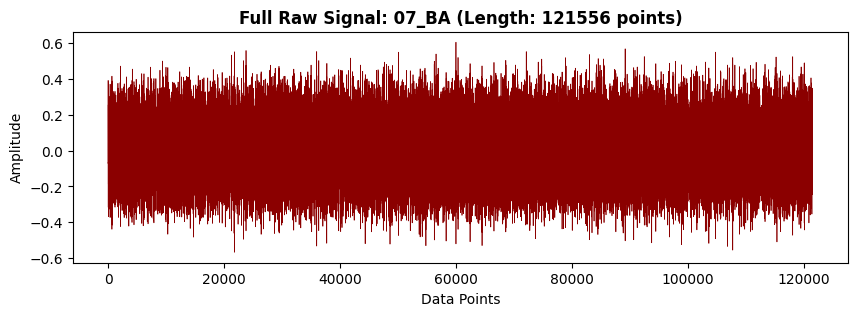

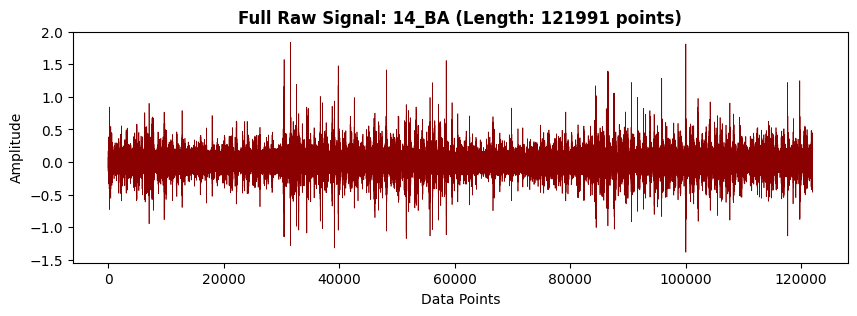

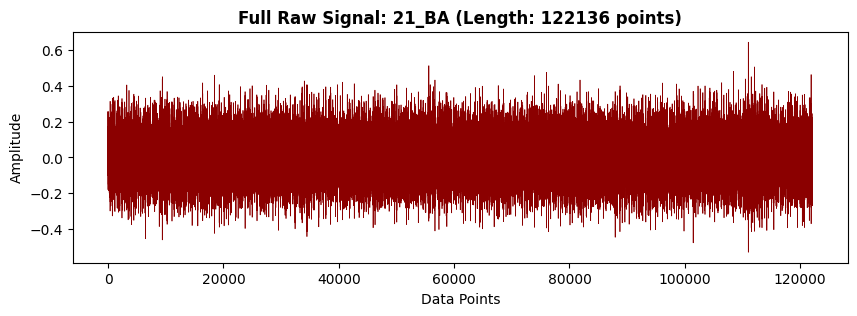

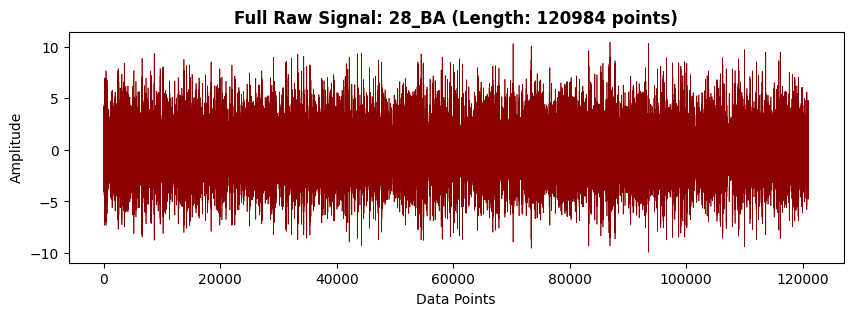

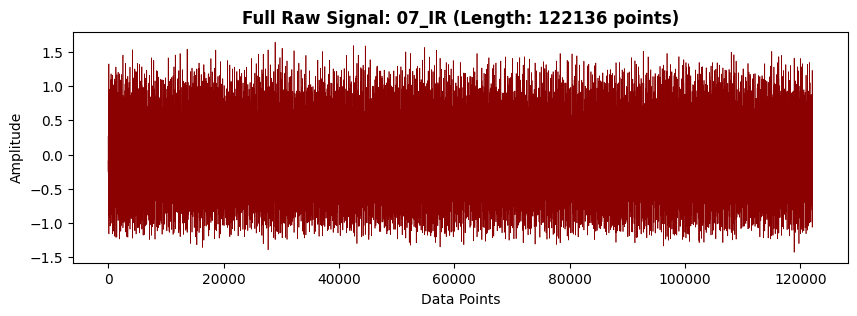

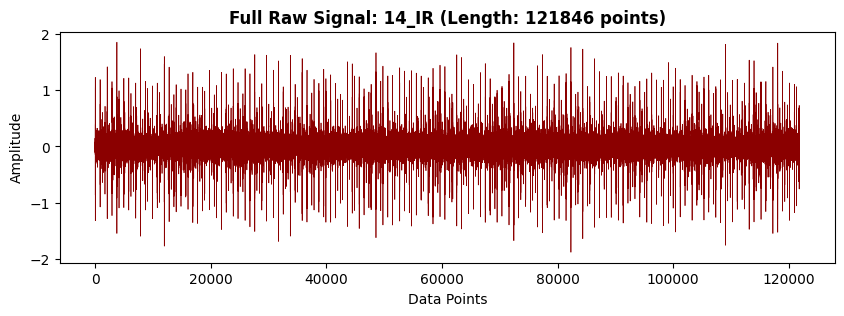

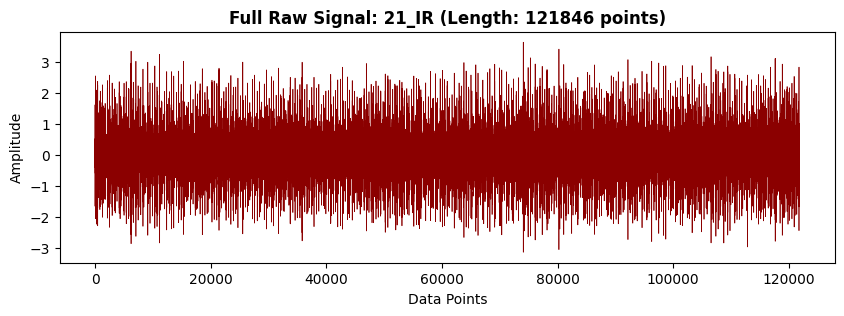

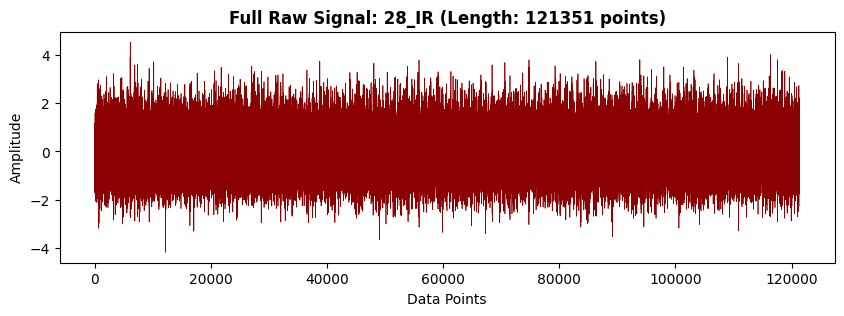

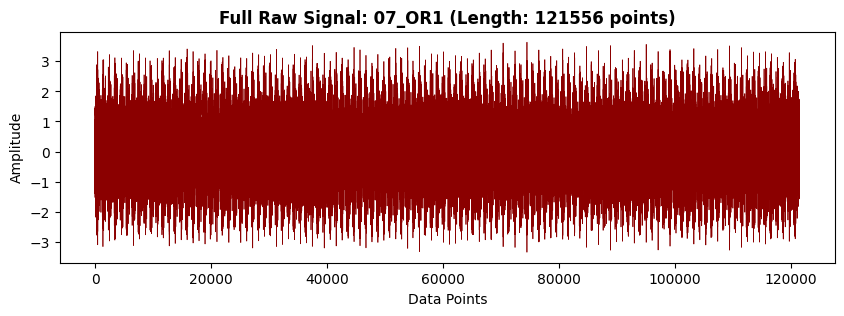

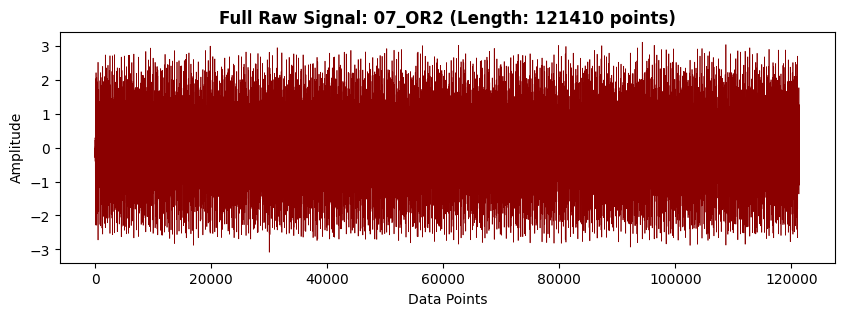

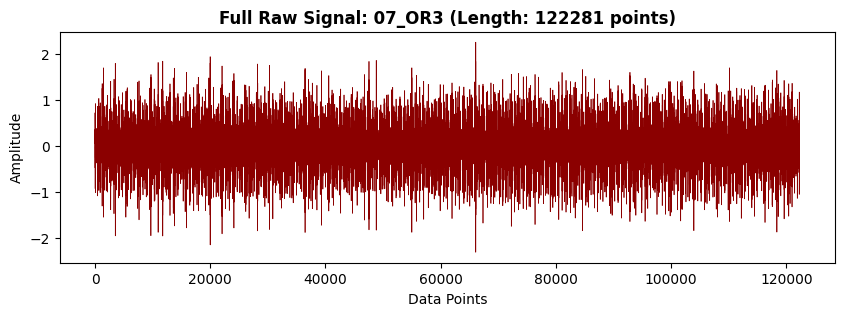

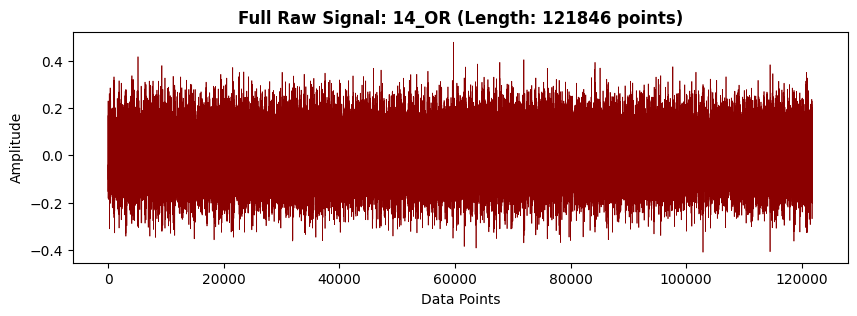

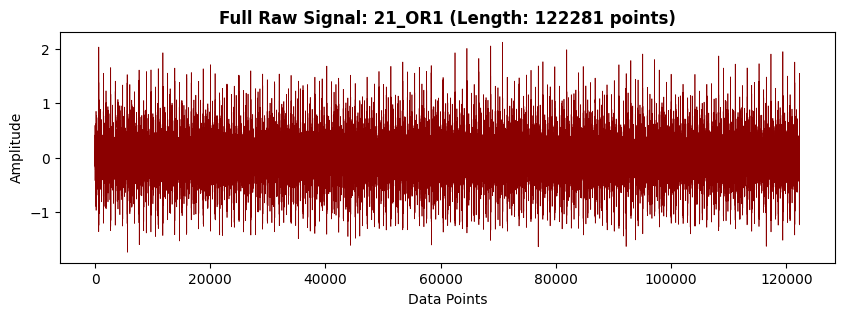

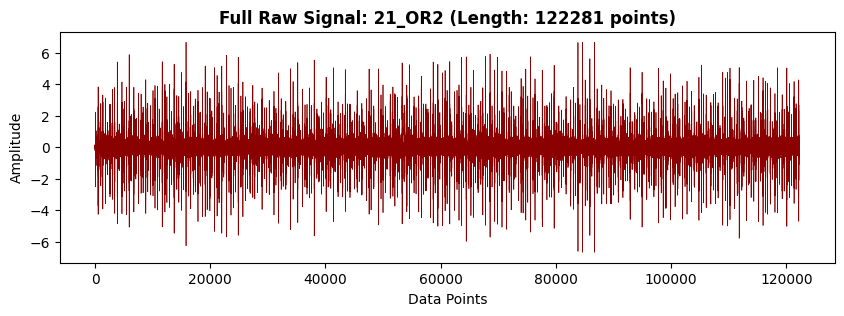

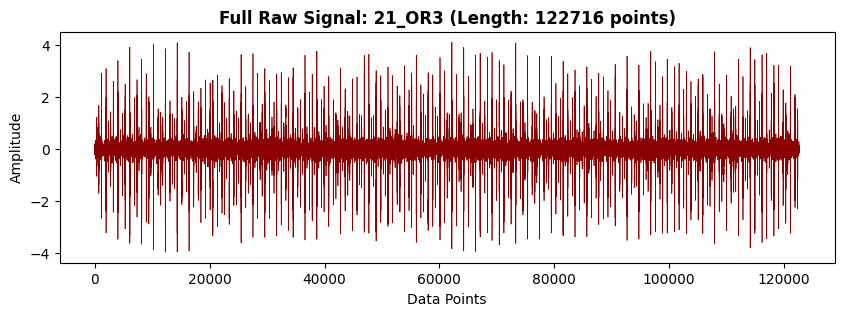

In [12]:
for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith('.mat'):
            path = os.path.join(root, file)
            name = file.replace('.mat', '')
            mat_data = scipy.io.loadmat(path)
            
            for key in mat_data.keys():
                if 'DE_time' in key:
                    signal = mat_data[key].flatten()

                    plt.figure(figsize=(10,3))
                    plt.plot(signal, color='darkred', linewidth=0.5)
                    # Notice the title will now show you exactly how many points are in each unique file!
                    plt.title(f"Full Raw Signal: {name} (Length: {len(signal)} points)", fontweight='bold')
                    plt.xlabel("Data Points")
                    plt.ylabel("Amplitude")
                    plt.show()

                    temp_df = pd.DataFrame({'DE_data': signal, 'fault': name})
                    all_data_frames.append(temp_df)
                    break

In [13]:
df_long = pd.concat(all_data_frames, ignore_index=True)
print(f"\nSuccess! 100% of data retained. Total points: {len(df_long)}")


Success! 100% of data retained. Total points: 2312120


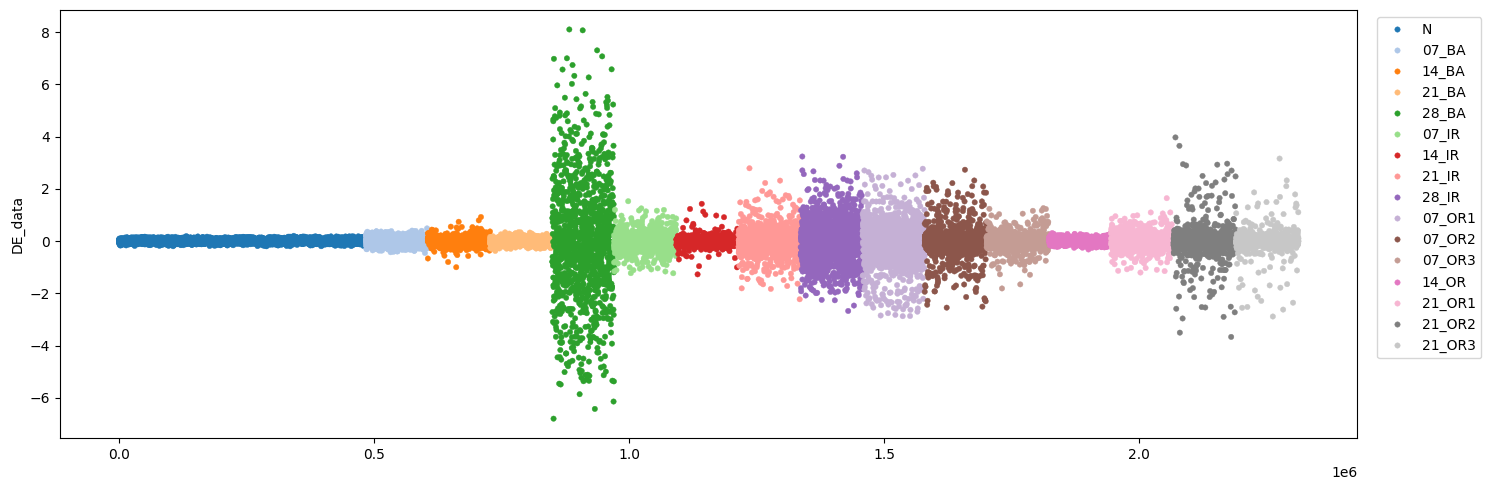

In [14]:
plt.figure(figsize=(15, 5))
sns.scatterplot(
    data=df_long.iloc[:: 100, :],
    x=np.arange(0, len(df_long), 100), 
    y='DE_data', 
    hue='fault',
    palette='tab20',
    s=15,
    edgecolor=None
)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 2312120 entries, 0 to 2312119
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   DE_data  float64
 1   fault    str    
dtypes: float64(1), str(1)
memory usage: 45.4 MB


In [19]:
print(df_long.head())
print(df_long.tail())

    DE_data fault
0  0.046104     N
1 -0.037134     N
2 -0.089496     N
3 -0.084906     N
4 -0.038594     N
          DE_data   fault
2312115 -0.037766  21_OR3
2312116 -0.020710  21_OR3
2312117  0.074720  21_OR3
2312118  0.089745  21_OR3
2312119 -0.054416  21_OR3


In [20]:
df_long.to_parquet('CWRU_raw_data_2_load.parquet', engine='pyarrow', index=False)
print("File saved successfully as CWRU_raw_data_2_load.parquet")

File saved successfully as CWRU_raw_data_2_load.parquet


In [26]:
df=pd.read_parquet('CWRU_raw_data_2_load.parquet')

In [25]:
df

,DE_data,fault
0,0.046104,N
1,-0.037134,N
2,-0.089496,N
3,-0.084906,N
4,-0.038594,N
...,...,...
2312115,-0.037766,21_OR3
2312116,-0.020710,21_OR3
2312117,0.074720,21_OR3
2312118,0.089745,21_OR3
